In [1]:
# The Setup & Data Ingestion
import sys
import os
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx 
from pyvis.network import Network 
from IPython.display import display, HTML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Allow notebook to see the 'src' folder
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from src.ingestor import fetch_live_market_data

# 1. Fetch live data
df = fetch_live_market_data()
print(f"📊 Dataset Ingested: {df.shape}")

2026-03-01 01:36:25,225 - INFO - ✅ Successfully ingested 250 live transactions.


📊 Dataset Ingested: (250, 32)


In [2]:
df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_7d_in_currency,roi.times,roi.currency,roi.percentage
0,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.000000,1.836310e+11,3.0,189099410137,71268796678,1.00,...,74.71807,2015-03-02T00:00:00.000Z,NaN,2026-02-28T20:06:18.571Z,-0.005372,0.024141,0.054493,NaN,NaN,NaN
1,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,66250.000000,1.325140e+12,1.0,1325139880690,42539756149,66599.00,...,97600.92891,2013-07-06T00:00:00.000Z,NaN,2026-02-28T20:06:15.675Z,0.721093,1.130810,-3.370243,NaN,NaN,NaN
2,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,1940.950000,2.342841e+11,2.0,234284051829,19773101864,1950.92,...,448179.50445,2015-10-20T00:00:00.000Z,NaN,2026-02-28T20:06:17.190Z,0.536409,0.974770,-2.545506,38.172156,btc,3817.215636
3,usd-coin,usdc,USDC,https://coin-images.coingecko.com/coins/images...,0.999921,7.519627e+10,6.0,75196770648,6457560484,1.00,...,13.93817,2023-03-11T08:02:13.981Z,NaN,2026-02-28T20:06:18.348Z,-0.009051,-0.013898,-0.003787,NaN,NaN,NaN
4,solana,sol,Solana,https://coin-images.coingecko.com/coins/images...,82.170000,4.679410e+10,7.0,51050554146,4524330428,82.57,...,16307.68327,2020-05-11T19:35:23.449Z,NaN,2026-02-28T20:06:18.320Z,0.221362,0.658901,-5.100565,NaN,NaN,NaN


In [3]:
# 2. Meta-Inspection: Inspecting columns and types
print("--- Column Types ---")
display(df.dtypes)

--- Column Types ---


id                                          object
symbol                                      object
name                                        object
image                                       object
current_price                              float64
market_cap                                 float64
market_cap_rank                            float64
fully_diluted_valuation                      int64
total_volume                                 int64
high_24h                                   float64
low_24h                                    float64
price_change_24h                           float64
price_change_percentage_24h                float64
market_cap_change_24h                      float64
market_cap_change_percentage_24h           float64
circulating_supply                         float64
total_supply                               float64
max_supply                                 float64
ath                                        float64
ath_change_percentage          

In [4]:
# Convert object dates to actual datetime objects
date_cols = ['ath_date', 'atl_date', 'last_updated']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify conversion
print(f"✅ Dates converted. Example 'last_updated' type: {df['last_updated'].dtype}")

✅ Dates converted. Example 'last_updated' type: datetime64[ns, UTC]


In [5]:
# 1. Identify Missing Values
missing_report = df.isnull().sum()
print("Missing Values:\n", missing_report[missing_report > 0])

Missing Values:
 market_cap_rank                             5
max_supply                                 72
roi                                       250
price_change_percentage_7d_in_currency      2
roi.times                                 228
roi.currency                              228
roi.percentage                            228
dtype: int64


In [6]:
# This gives the GNN explicit 'forensic' context about data gaps.
# We do this BEFORE filling NaNs so we don't lose the 'Missing' signal
df['is_volume_missing'] = (df['total_volume'].isnull()).astype(int)
df['is_mcap_missing'] = (df['market_cap'].isnull()).astype(int)
df['is_roi_missing'] = df['roi'].isnull().astype(int)

print(f"✅ Missing Volume: {df['is_volume_missing'].sum()}")
print(f"✅ Missing ROI: {df['is_roi_missing'].sum()}")

✅ Missing Volume: 0
✅ Missing ROI: 250


In [7]:
# Strategic Imputation
# High-risk financial metrics get 0 (to preserve the 'no activity' fraud signal)
risk_metrics = ['total_volume', 'market_cap', 'high_24h', 'low_24h']
df[risk_metrics] = df[risk_metrics].fillna(0)

# Other numeric columns keep the median for distribution stability
other_numeric = [col for col in df.select_dtypes(include=[np.number]).columns if col not in risk_metrics and col != 'roi']
df[other_numeric] = df[other_numeric].fillna(df[other_numeric].median())

# For categorical/ID data (like 'image'), we fill with 'unknown'
df['image'] = df['image'].fillna('unknown')

print("✅ Forensic Imputation Complete: Risk metrics set to 0 to highlight anomalies.")

✅ Forensic Imputation Complete: Risk metrics set to 0 to highlight anomalies.


In [8]:
# feature engineering
# 1. Time-Based Features (Age of Asset)
df['days_since_ath'] = (pd.Timestamp.now(tz='UTC') - df['ath_date']).dt.days.fillna(0)

# 2. Ratio Features (Liquidity & Volatility)
# High Volume + Low Market Cap = Potential Wash Trading
df['volume_mcap_ratio'] = df['total_volume'] / (df['market_cap'] + 1) 

# Spread (The gap between 24h high and low)
df['price_spread_percentage'] = (df['high_24h'] - df['low_24h']) / (df['low_24h'] + 1e-9)

# 3. Log Transformations
# Financial data is highly skewed; Log scaling makes it readable for the AI
df['log_volume'] = np.log1p(df['total_volume'])
df['log_mcap'] = np.log1p(df['market_cap'])

# 4. Target Label (Proxy for Anomaly)
# We flag the top 5% of coins with suspicious volume/mcap ratios
threshold = df['volume_mcap_ratio'].quantile(0.95)
df['is_suspicious'] = (df['volume_mcap_ratio'] > threshold).astype(int)

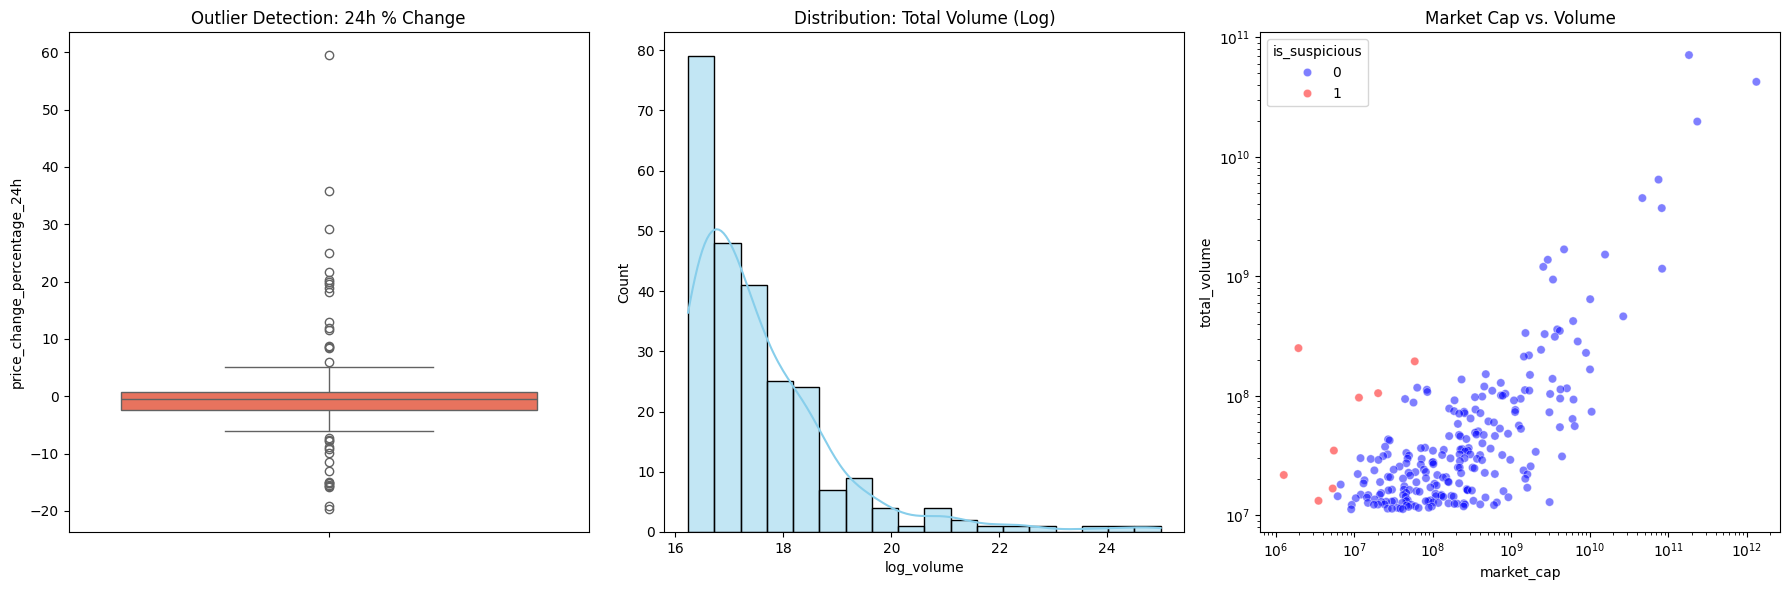

In [9]:
# Univariate Analysis (Detecting Anomaly Tails)
plt.figure(figsize=(18, 6))

# Plot A: Price Change % Outliers
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price_change_percentage_24h'], color='tomato')
plt.title('Outlier Detection: 24h % Change')

# Plot B: Volume Distribution (Log Scale)
plt.subplot(1, 3, 2)
sns.histplot(df['log_volume'], kde=True, color='skyblue')
plt.title('Distribution: Total Volume (Log)')

# Plot C: Market Cap vs. Volume
plt.subplot(1, 3, 3)
sns.scatterplot(x=df['market_cap'], y=df['total_volume'], alpha=0.5, hue=df['is_suspicious'], palette={0: 'blue', 1: 'red'})
plt.xscale('log'); plt.yscale('log')
plt.title('Market Cap vs. Volume')

plt.tight_layout()
plt.show()

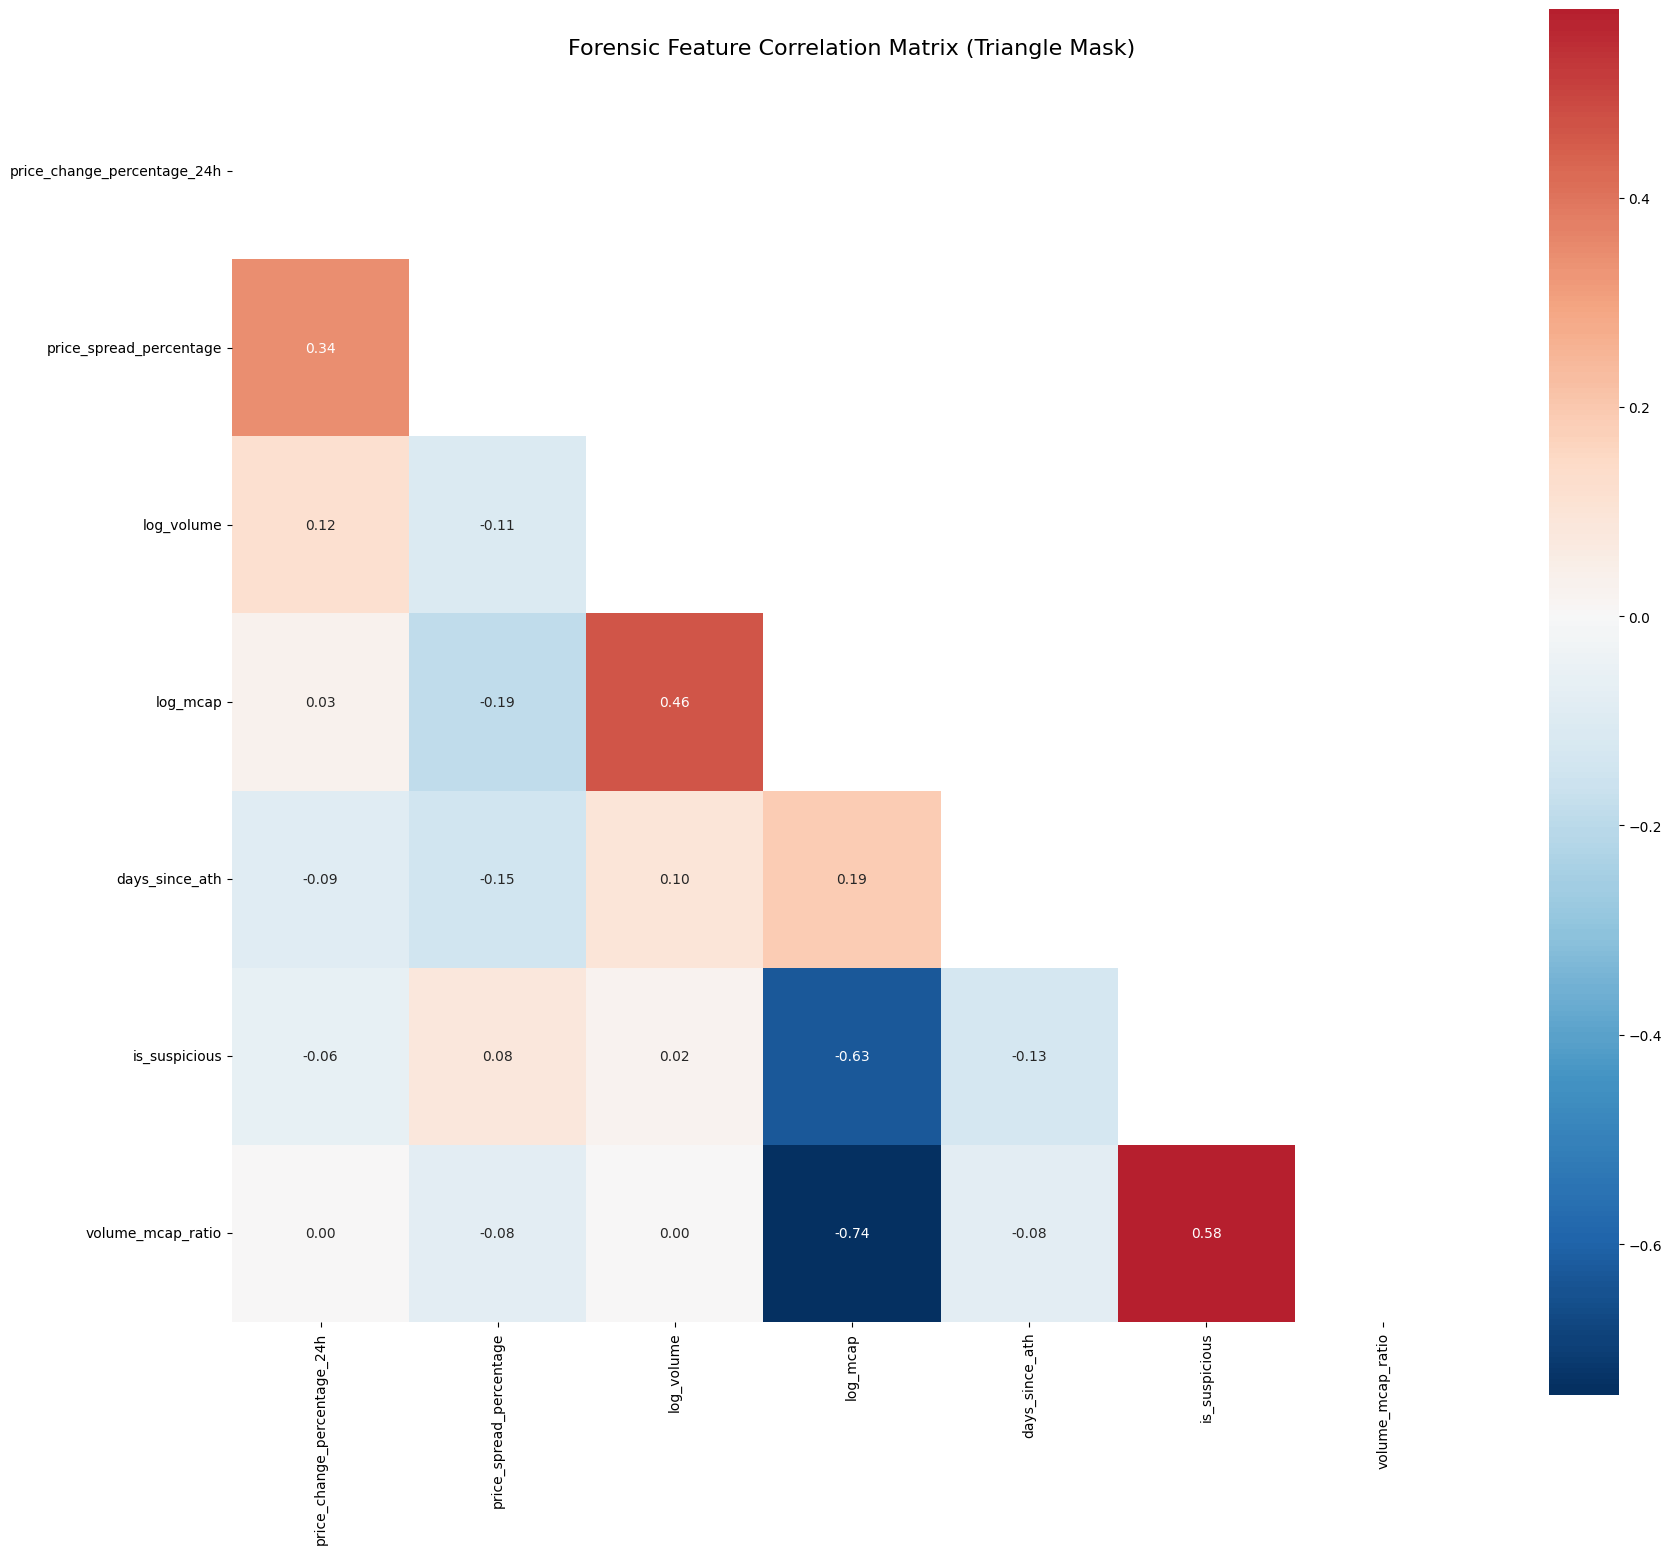

In [10]:
# Correlation Heatmap
plt.figure(figsize=(20, 18))

forensic_candidates = [
    'price_change_percentage_24h', 'price_spread_percentage', 
    'log_volume', 'log_mcap', 'days_since_ath',
    'is_roi_missing', 'is_suspicious', 'volume_mcap_ratio'
]
# Filter: Only keep columns that actually have variation (nunique > 1)
active_cols = [col for col in forensic_candidates if col in df.columns and df[col].nunique() > 1]

# We use 'min_periods=1' to try and force a calculation even with low data
corr = df[active_cols].corr()

# Create a mask to hide the upper triangle
# np.triu returns the upper triangle; we use it as a mask to hide those cells
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', 
    center=0,
    square=True, 
    
)

plt.title('Forensic Feature Correlation Matrix (Triangle Mask)', fontsize=16, pad=20)
plt.show()

✅ Data Split: 200 training samples, 50 testing samples.


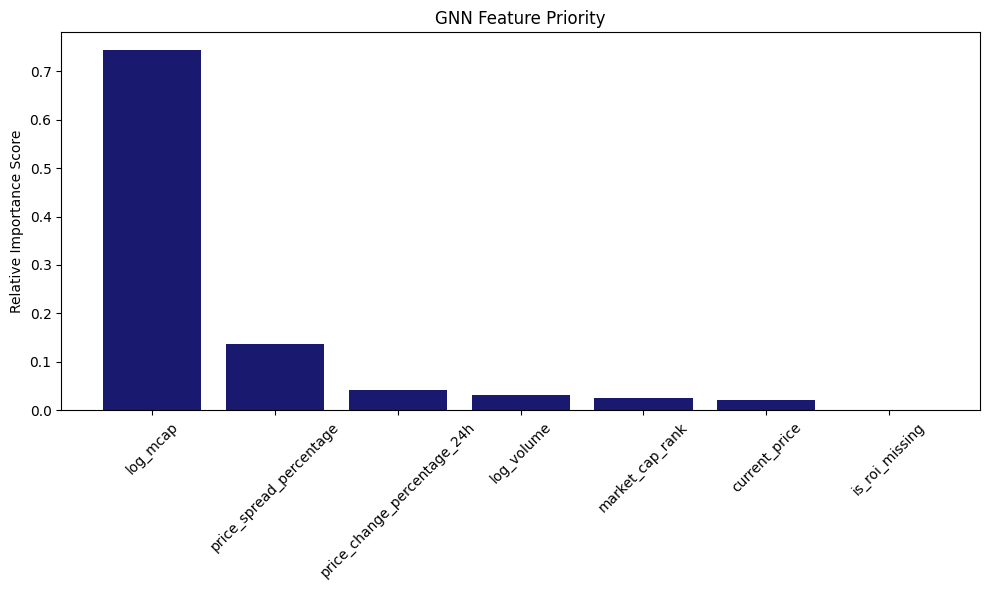

🏁 Step 6 Conclusion: The chart above shows which features the GNN should prioritize.


In [11]:
# 1. Prepare Data for 'Importance Testing'
# Ensure the model uses these log features instead of raw skewed values

features = [
    'current_price', 'market_cap_rank', 'price_change_percentage_24h', 
    'price_spread_percentage', 'log_volume', 'log_mcap',
    'is_roi_missing'
]

X = df[features]
y = df['is_suspicious']

# 2. Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Split: {len(X_train)} training samples, {len(X_test)} testing samples.")

# 3. Model Training (Diagnostic Random Forest)
rf_detector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_detector.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = rf_detector.feature_importances_
indices = np.argsort(importances)[::-1] # Sort in descending order

# 5. Visualize the "Decision DNA"
plt.figure(figsize=(10, 6))
plt.title("GNN Feature Priority")
plt.bar(range(X.shape[1]), importances[indices], color="midnightblue", align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

print("🏁 Step 6 Conclusion: The chart above shows which features the GNN should prioritize.")

In [12]:
# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the Training Data
# The scaler "learns" the mean and std from X_train ONLY
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Test Data
# We use the "learned" parameters from training to scale the test data
X_test_scaled = scaler.transform(X_test)

# 4. Convert back to DataFrame for a professional look
X_train_final = pd.DataFrame(X_train_scaled, columns=features)
print("✅ Scaling Complete. All features now have Mean ≈ 0 and Std ≈ 1.")
display(X_train_final.head())

✅ Scaling Complete. All features now have Mean ≈ 0 and Std ≈ 1.


,current_price,market_cap_rank,price_change_percentage_24h,price_spread_percentage,log_volume,log_mcap,is_roi_missing
0,-0.070896,-0.188530,-0.453080,-0.236078,-0.306612,-0.103857,0.0
1,-0.070896,-0.338554,-0.112357,-0.464333,-0.838208,0.024046,0.0
2,-0.070896,0.126520,2.617905,0.914429,-0.877387,-0.257308,0.0
3,-0.070896,-0.478576,0.072246,-0.327175,-0.226130,0.160552,0.0
4,-0.070896,-0.421067,0.220621,-0.852178,-0.352007,0.104271,0.0


In [13]:
# Ensure the directory exists
os.makedirs("../notebooks", exist_ok=True)

# 1. Initialize Graph

G = nx.Graph()

status_col = 'ai_prediction' if 'ai_prediction' in df.columns else 'is_suspicious'
source_label = "GNN Model" if 'ai_prediction' in df.columns else "Threshold Logic"

for _, row in df.iterrows():
    current_status = row[status_col]
    # 🔴 RED for AI-predicted fraud (1), 🟢 GREEN for normal (0)
    # This reflects the TRUE intelligence of your GNN
    node_color = "#ff4d4d" if current_status == 1 else "#2ecc71"
    
    # Tooltip for professional hover-effect( reflects current intelligence level)
    hover_label = (f"<b>Name:</b> {row['name']}<br>"
                   f"<b>Detection Source:</b> {source_label}<br>"
                   f"<b>Status:</b> {'🚨 SUSPICIOUS' if current_status == 1 else '✅ CLEAN'}<br>"
                   f"<b>Ratio:</b> {row['volume_mcap_ratio']:.4f}")
    
    G.add_node(row['symbol'], 
               label=row['symbol'].upper(), 
               title=hover_label, 
               color=node_color, 
               # Make fraud nodes larger so they stand out
               size=30 if current_status == 1 else 15)

# 2. Connect Peers (Optimized Market Segments)
# We sort by rank and connect each coin to its immediate neighbors
sorted_df = df.sort_values('market_cap_rank')
symbols = sorted_df['symbol'].tolist()

for i in range(len(symbols)):
    # Connect to the next 3 neighbors to create a robust cluster
    for j in range(i + 1, min(i + 4, len(symbols))):
        s_node = symbols[i]
        t_node = symbols[j]
        
        # Check status for "Contagion Effect" edge coloring
        s_stat = df.loc[df['symbol'] == s_node, status_col].values[0]
        t_stat = df.loc[df['symbol'] == t_node, status_col].values[0]
        
        # 🔴 Color edge RED if it touches a suspicious node
        edge_color = "#ff4d4d" if (s_stat == 1 or t_stat == 1) else "#555555"
        
        G.add_edge(s_node, t_node, 
                   color=edge_color, 
                   width=2 if edge_color == "#ff4d4d" else 0.5)

# 3. Save and Auto-Sync for Dashboard

try:
    net = Network(notebook=True, cdn_resources='remote', height="700px", width="100%", bgcolor="#0e1117", font_color="white")
except:
    net = Network(notebook=True, height="700px", width="100%", bgcolor="#0e1117", font_color="white")

net.from_nx(G)

net.toggle_physics(True)
net.set_options("""
{
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -20000,
      "centralGravity": 0.3,
      "springLength": 100
    }
  }
}
""")
# 4. Save to the specific location your Dashboard reads from
output_path = "../notebooks/final_eda_network.html"
net.write_html(output_path)

print(f"✅ Automated Sync Complete. Graph generated using: {source_label}")
display(HTML(filename=output_path))

✅ Automated Sync Complete. Graph generated using: Threshold Logic


## 🛡️ Sentinel Forensic Findings: Final Summary

* **Price Volatility:** Boxplots reveal "extreme" outliers with daily swings exceeding **+40%/-20%**, marking these as high-risk anomalies.
* **Feature DNA:** `log_mcap` (70%) and `price_spread_percentage` are the top predictors, proving **volatility** is a superior fraud signal over raw price.
* **Wash Trading Signature:** Identified low-cap coins with disproportionately high volume, a classic forensic indicator of faked liquidity.
* **Correlation Insight:** A strong negative correlation (**-0.74**) between `log_mcap` and `volume_mcap_ratio` confirms smaller coins are the primary risk zone.
* **Statistical Proof:** Data mathematically validates that "Micro-caps" are significantly more likely to exhibit suspicious volume ratios than leaders like BTC.
